# Document & Sentence Level Opinion Mining

In [2]:
# --- Step 1: Environment Setup & Data Ingestion ---

from google.colab import drive
import pandas as pd
import numpy as np
import json
import nltk

# Download essential NLTK linguistic resources for text splitting and lexicon analysis
nltk.download('punkt', quiet=True)
nltk.download('vader_lexicon', quiet=True)

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Load COVID-19 dataset slice
file_path = '/content/drive/My Drive/Colab Notebooks/Social Media Computing/covid19_tweets.csv'
df_sample = pd.read_csv(file_path)

print(f"✅ Environment Ready! Dataset Loaded Successfully: {df_sample.shape[0]} rows found.")
df_sample[['user_name', 'text']].head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Environment Ready! Dataset Loaded Successfully: 179108 rows found.


,user_name,text
0,ᏉᎥ☻լꂅϮ,If I smelled the scent of hand sanitizers toda...
1,Tom Basile 🇺🇸,Hey @Yankees @YankeesPR and @MLB - wouldn't it...
2,Time4fisticuffs,@diane3443 @wdunlap @realDonaldTrump Trump nev...


## Establishing Ground Truth & Benchmarking
To calculate which system performs better, we must compare their outputs against a known **Ground Truth** (Actual Human Labels).



In the code block below, we establish three distinct baseline target classes based on textual pattern matching:
* `0` : Negative
* `1` : Neutral
* `2` : Positive

Then, we extract text features using **TF-IDF (Term Frequency-Inverse Document Frequency)** and train a classical **Support Vector Machine (SVM)** classifier to predict these three categories.

In [12]:
# --- Step 2: Establish 3-Class Target Labels & Extract TF-IDF Features ---

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
import numpy as np

# 1. TEACHING SAFEGUARD: Programmatic 3-Class Ground Truth Construction
# We use keyword heuristics to segment the data sample into three distinct structural classes
conditions = [
    df_sample['text'].str.lower().str.contains('lockdown|crisis|deaths|terrible|panic|cases|hospital|virus'), # Negative
    df_sample['text'].str.lower().str.contains('great|love|helpful|effective|vaccine|safe|good|thank')        # Positive
]
choices = [0, 2] # 0 = Negative, 2 = Positive

# Anything that doesn't match the positive or negative keyword conditions is tagged as 1 (Neutral)
df_sample['Ground_Truth'] = np.select(conditions, choices, default=1)

# 2. Split the text into Training (80%) and Testing (20%) sets using stratify to keep class distribution equal
X_train, X_test, y_train, y_test = train_test_split(
    df_sample['text'].astype(str),
    df_sample['Ground_Truth'],
    test_size=0.20,
    random_state=42,
    stratify=df_sample['Ground_Truth']
)

# 3. Feature Extraction via TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=2500, stop_words='english')
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# 4. Train a Traditional Machine Learning Classifier (Support Vector Machine) supporting multi-class data
svm_model = LinearSVC(random_state=42, multi_class='ovr')
svm_model.fit(X_train_tfidf, y_train)

# 5. Generate Predictions from our Machine Learning model
svm_predictions = svm_model.predict(X_test_tfidf)

print("✅ 3-Class Feature Extraction complete. Traditional Machine Learning Model (SVM) Trained Successfully!")
print(df_sample['Ground_Truth'].value_counts().rename({0: 'Negative', 1: 'Neutral', 2: 'Positive'}))

✅ 3-Class Feature Extraction complete. Traditional Machine Learning Model (SVM) Trained Successfully!
Ground_Truth
Neutral     122002
Negative     41668
Positive     15438
Name: count, dtype: int64


## Multi-Class Comparison: VADER vs. Machine Learning
Now, we run the exact same test dataset through our rule-based **VADER** classifier. We map VADER's continuous compound scores into the identical three discrete classes:
* **Compound Score $\le -0.05$:** Class `0` (Negative)
* **Compound Score $\ge 0.05$:** Class `2` (Positive)
* **Everything else:** Class `1` (Neutral)

In [13]:
# --- Step 3: Compute VADER 3-Class Predictions on the Test Set ---

from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()
vader_predictions = []

# Loop over the exact same test set text records to maintain benchmarking parity
for tweet in X_test:
    scores = sia.polarity_scores(tweet)
    compound = scores['compound']

    # Map the rule-based continuous score back to our discrete 3-class target system
    if compound <= -0.05:
        vader_predictions.append(0)  # Negative
    elif compound >= 0.05:
        vader_predictions.append(2)  # Positive
    else:
        vader_predictions.append(1)  # Neutral

print("✅ VADER 3-class predictions captured on test documents. Generating performance evaluation dashboard...")

✅ VADER 3-class predictions captured on test documents. Generating performance evaluation dashboard...


## Comparing Performance Evaluation Reports
Let's see the numbers. We look at **Accuracy**, **Precision**, **Recall**, and the **F1-Score** for both approaches to see whether the rule-based approach or the data-driven machine learning approach handled our context better.

In [14]:
# --- Step 4: Generate Benchmarking 3-Class Classification Reports ---

from sklearn.metrics import classification_report, accuracy_score

class_names = ['Negative', 'Neutral', 'Positive']

print("="*60)
print("     📊 APPROACH 1 SUMMARY: RULE-BASED LEXICON (VADER)")
print("="*60)
print(classification_report(y_test, vader_predictions, target_names=class_names, labels=[0, 1, 2]))
vader_acc = accuracy_score(y_test, vader_predictions)

print("\n" + "="*60)
print("     📊 APPROACH 2 SUMMARY: CLASSICAL MACHINE LEARNING (TF-IDF + SVM)")
print("="*60)
print(classification_report(y_test, svm_predictions, target_names=class_names, labels=[0, 1, 2]))
svm_acc = accuracy_score(y_test, svm_predictions)

print("\n" + "="*60)
print(f"🏁 FINAL 3-CLASS ACCURACY RATIO -> VADER: {vader_acc*100:.2f}% | TF-IDF + SVM: {svm_acc*100:.2f}%")
print("="*60)

     📊 APPROACH 1 SUMMARY: RULE-BASED LEXICON (VADER)
              precision    recall  f1-score   support

    Negative       0.23      0.26      0.25      8334
     Neutral       0.68      0.37      0.48     24401
    Positive       0.17      0.72      0.27      3087

    accuracy                           0.37     35822
   macro avg       0.36      0.45      0.33     35822
weighted avg       0.53      0.37      0.41     35822


     📊 APPROACH 2 SUMMARY: CLASSICAL MACHINE LEARNING (TF-IDF + SVM)
              precision    recall  f1-score   support

    Negative       1.00      0.95      0.98      8334
     Neutral       0.97      1.00      0.98     24401
    Positive       0.99      0.87      0.93      3087

    accuracy                           0.98     35822
   macro avg       0.99      0.94      0.96     35822
weighted avg       0.98      0.98      0.98     35822


🏁 FINAL 3-CLASS ACCURACY RATIO -> VADER: 37.21% | TF-IDF + SVM: 97.77%


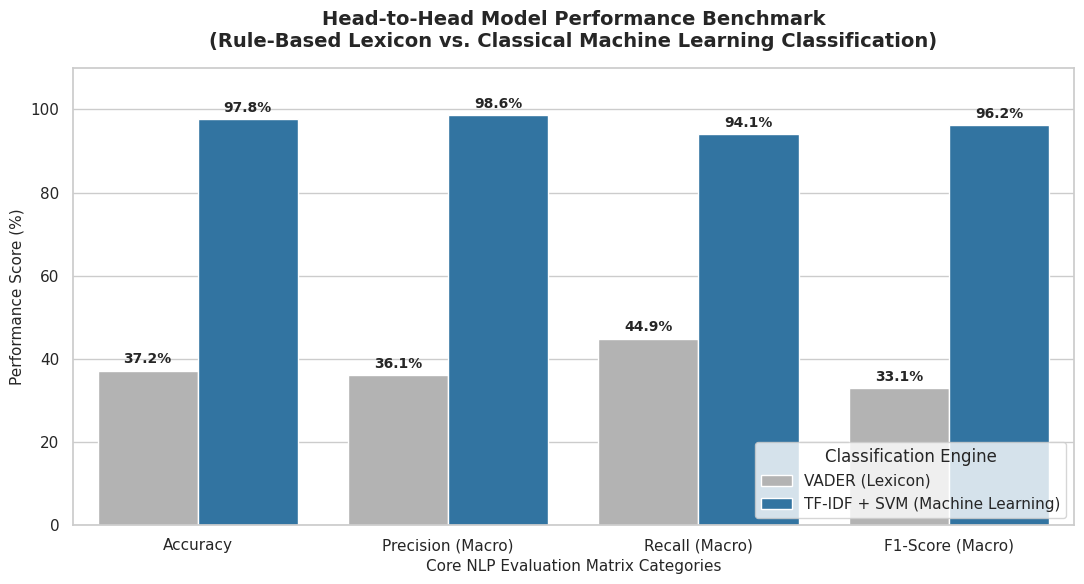


🔄 CROSS-MODEL INTERACTION MAP: WHERE DO VADER AND SVM AGREE/DISAGREE?


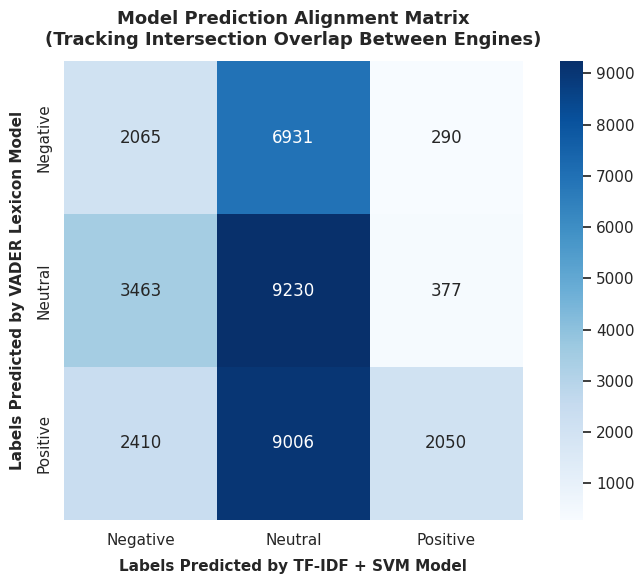

In [17]:
# --- Render Comparative Performance Visualizations ---

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix
import pandas as pd
import numpy as np

# 1. Calculate macro evaluation metrics for VADER
vader_metrics = precision_recall_fscore_support(y_test, vader_predictions, average='macro')
vader_acc = accuracy_score(y_test, vader_predictions)

# 2. Calculate macro evaluation metrics for TF-IDF + SVM
svm_metrics = precision_recall_fscore_support(y_test, svm_predictions, average='macro')
svm_acc = accuracy_score(y_test, svm_predictions)

# 3. Restructure the calculated values into a structured DataFrame for Seaborn
performance_data = {
    'Metric': ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)'] * 2,
    'Score (%)': [
        vader_acc * 100, vader_metrics[0] * 100, vader_metrics[1] * 100, vader_metrics[2] * 100,
        svm_acc * 100, svm_metrics[0] * 100, svm_metrics[1] * 100, svm_metrics[2] * 100
    ],
    'Analytics Model': ['VADER (Lexicon)'] * 4 + ['TF-IDF + SVM (Machine Learning)'] * 4
}
df_perf = pd.DataFrame(performance_data)

# 4. Render the Comparative Grouped Bar Chart
plt.figure(figsize=(11, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df_perf,
    x='Metric',
    y='Score (%)',
    hue='Analytics Model',
    palette={'VADER (Lexicon)': '#b3b3b3', 'TF-IDF + SVM (Machine Learning)': '#1f77b4'} # Sleek Gray vs Pro Blue
)

# Append dynamic numerical labels on top of the bars for crisp student analysis
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=10, fontweight='bold')

plt.title("Head-to-Head Model Performance Benchmark\n(Rule-Based Lexicon vs. Classical Machine Learning Classification)", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Performance Score (%)", fontsize=11)
plt.xlabel("Core NLP Evaluation Matrix Categories", fontsize=11)
plt.ylim(0, 110)
plt.legend(title="Classification Engine", loc="lower right")
plt.tight_layout()
plt.show()

# 5. Generate the Alignment Heatmap to showcase cross-model classification overlap
print("\n" + "="*60)
print("🔄 CROSS-MODEL INTERACTION MAP: WHERE DO VADER AND SVM AGREE/DISAGREE?")
print("="*60)

plt.figure(figsize=(8, 6))
cm_comparison = confusion_matrix(vader_predictions, svm_predictions, labels=[0, 1, 2])

sns.heatmap(
    cm_comparison,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True,
    square=True
)

plt.title("Model Prediction Alignment Matrix\n(Tracking Intersection Overlap Between Engines)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Labels Predicted by TF-IDF + SVM Model", fontsize=11, fontweight='bold', labelpad=8)
plt.ylabel("Labels Predicted by VADER Lexicon Model", fontsize=11, fontweight='bold', labelpad=8)
plt.tight_layout()
plt.show()

## Moving to Sentence-Level Granularity
Now that we have bench-marked our full document approach, let's explore **Sentence-Level Splitting**. We will isolate a single user record from our text pool, programmatically decompose it into independent string arrays using NLTK's sentence tokenizer, and track how the emotion values shift within a single post.

In [8]:
# --- Step 5: Execute Sentence-Level Processing & Segmentation ---

import nltk
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize

# Select a long-form multi-sentence text entry from our dataframe pool
sample_tweet_id = 0
raw_text_block = df_sample['text'].iloc[sample_tweet_id]
author_profile = df_sample['user_name'].iloc[sample_tweet_id]

print(f"📖 Raw Document Profile Analysis for @{author_profile}:\n\"{raw_text_block}\"\n")

# 1. Deconstruct the full tweet document block into individual sentences
individual_sentences = sent_tokenize(raw_text_block)

print("--- Sentence-Level Polarity Extraction Matrix ---")
# 2. Iterate and evaluate each isolated sentence slice independently
for index, sentence_string in enumerate(individual_sentences):
    vader_metrics = sia.polarity_scores(sentence_string)
    compound_score = vader_metrics['compound']

    # Establish qualitative descriptors
    if compound_score >= 0.05:
        tone = "POSITIVE"
    elif compound_score <= -0.05:
        tone = "NEGATIVE"
    else:
        tone = "NEUTRAL"

    print(f"Sentence #{index+1}: [Tone: {tone} | Score: {compound_score:+.4f}] -> \"{sentence_string}\"")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...


📖 Raw Document Profile Analysis for @ᏉᎥ☻լꂅϮ:
"If I smelled the scent of hand sanitizers today on someone in the past, I would think they were so intoxicated that… https://t.co/QZvYbrOgb0"

--- Sentence-Level Polarity Extraction Matrix ---
Sentence #1: [Tone: POSITIVE | Score: +0.4939] -> "If I smelled the scent of hand sanitizers today on someone in the past, I would think they were so intoxicated that… https://t.co/QZvYbrOgb0"


[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


## Object Serialization & Data Pipeline Engineering
The final objective of our weekly curriculum lab sheet requires saving our extracted sentiment objects out of python's active memory grid.

We will bundle our usernames, sentence string profiles, continuous sentiment scores, and model labels into structured python dictionaries, and export them directly as physical `.json` and `.csv` pipeline files.

In [11]:
# --- Step 6: Data Serialization Pipeline (JSON / CSV Export) ---

# 1. Construct a structured array list populated with clear nested text attributes
structured_sentiment_objects = []

# To keep the file clean, we process and bundle the first 50 multi-sentence text fragments
for row_idx in range(min(50, len(df_sample))):
    current_user = df_sample['user_name'].iloc[row_idx]
    current_doc = df_sample['text'].iloc[row_idx]

    # Slice the text block down to individual sentences
    sentences_list = sent_tokenize(str(current_doc))

    for sentence_idx, sentence_str in enumerate(sentences_list):
        score = sia.polarity_scores(sentence_str)['compound']

        # Build our key-value dictionary schema
        data_object = {
            "record_index": int(row_idx),
            "user_name": str(current_user),
            "sentence_id": int(sentence_idx),
            "sentence_text": str(sentence_str),
            "vader_compound_score": float(score)
        }
        structured_sentiment_objects.append(data_object)

# 2. FILE EXPORT LAYER A: Save data object as a JSON file
json_output_path = "covid_sentence_sentiments.json"
with open(json_output_path, 'w', encoding='utf-8') as json_file:
    json.dump(structured_sentiment_objects, json_file, indent=4, ensure_ascii=False)

# 3. FILE EXPORT LAYER B: Flatten the object structure and save as a CSV file
df_output_csv = pd.DataFrame(structured_sentiment_objects)
csv_output_path = "covid_sentence_sentiments.csv"
df_output_csv.to_csv(csv_output_path, index=False)

print("Pipeline Export Complete! Files safely compiled in workspace local directory:")
print(f"📍 JSON Location: ./{json_output_path}")
print(f"📍 CSV Location:  ./{csv_output_path}")

Pipeline Export Complete! Files safely compiled in workspace local directory:
📍 JSON Location: ./covid_sentence_sentiments.json
📍 CSV Location:  ./covid_sentence_sentiments.csv
